In [ ]:
# Find multiples of 2 up to 20
import numpy as np
import pandas as pd

df = pd.read_csv("/content/cleaned_student_depression.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [ ]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
X_train.select_dtypes(include='object').columns
X_train.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
1657,8551,Male,18.0,Jaipur,Student,4.0,0.0,6.02,1.0,0.0,7-8 hours,Moderate,Class 12,Yes,3.0,5.0,No
24995,125925,Male,25.0,Vadodara,Student,3.0,0.0,6.37,2.0,0.0,7-8 hours,Moderate,B.Arch,No,9.0,1.0,Yes
27613,139260,Male,30.0,Ahmedabad,Student,3.0,0.0,9.24,2.0,0.0,7-8 hours,Unhealthy,M.Ed,Yes,5.0,5.0,Yes
13512,68491,Male,34.0,Bhopal,Student,3.0,0.0,7.37,5.0,0.0,7-8 hours,Moderate,B.Com,Yes,12.0,3.0,No
27029,136261,Male,25.0,Patna,Student,3.0,0.0,7.47,4.0,0.0,5-6 hours,Unhealthy,B.Com,No,11.0,5.0,No


In [ ]:
df = pd.get_dummies(df, drop_first=True)
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
X_train.isnull().sum().sort_values(ascending=False)

,0
Financial Stress,2
id,0
Academic Pressure,0
Work Pressure,0
CGPA,0
...,...
Degree_MSc,0
Degree_Others,0
Degree_PhD,0
Have you ever had suicidal thoughts ?_Yes,0


In [ ]:
X_train.isnull().sum().sum()

np.int64(2)

In [ ]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0
Financial Stress,2


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = lr_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.842501343845189
Precision: 0.8522559716897671
Recall   : 0.8843329253365974
F1 Score : 0.8679981979276168


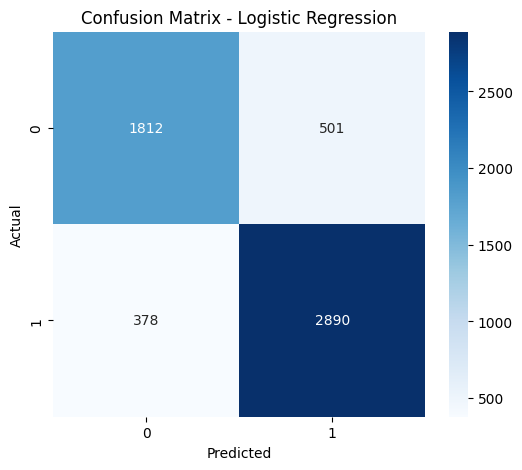

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2313
           1       0.85      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



In [ ]:
# random forest-----
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)# this is for training the model

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test) # this is for making predictions

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.8364092456549006
Precision: 0.8470380194518126
Recall   : 0.879436964504284
F1 Score : 0.862933493469449


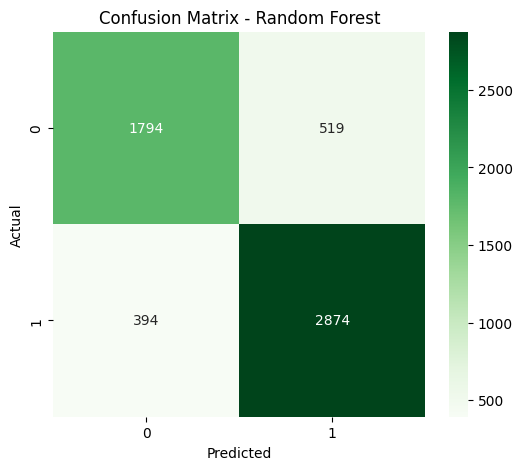

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



In [ ]:
# SVM-- support vector machine----
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# svm model
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

In [ ]:
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.8383802185988174
Precision: 0.8489675516224189
Recall   : 0.8806609547123623
F1 Score : 0.8645238810453589


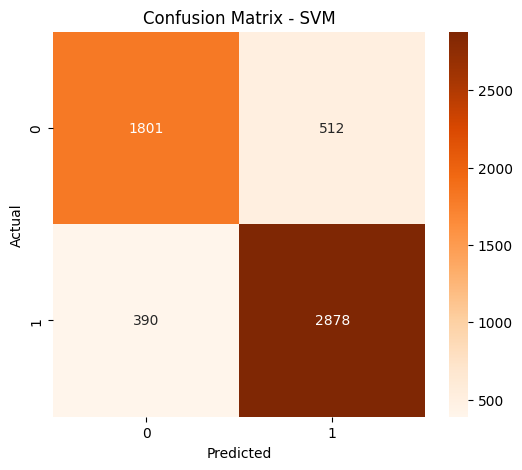

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



In [ ]:
results = []
results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm)
})

In [ ]:
# Naive bais---
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Accuracy : 0.7917935853789644
Precision: 0.782608695652174
Recall   : 0.8922888616891065
F1 Score : 0.8338575922219045


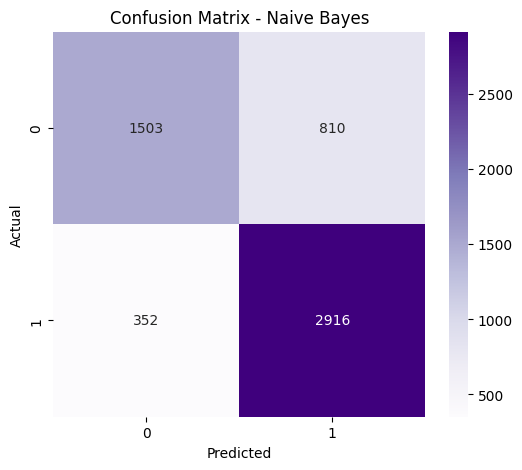

              precision    recall  f1-score   support

           0       0.81      0.65      0.72      2313
           1       0.78      0.89      0.83      3268

    accuracy                           0.79      5581
   macro avg       0.80      0.77      0.78      5581
weighted avg       0.79      0.79      0.79      5581



In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

print(classification_report(y_test, y_pred_nb))

In [ ]:
results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1 Score": f1_score(y_test, y_pred_nb)
})

In [ ]:
# xg boost-----

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.8469808278086365
Precision: 0.8585858585858586
Recall   : 0.8843329253365974
F1 Score : 0.8712692191739524


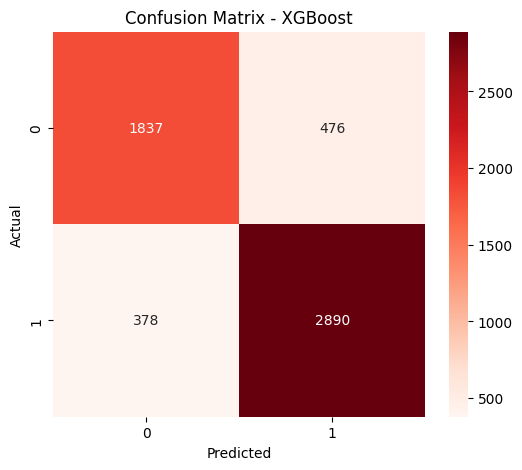

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.85      0.85      0.85      5581



In [ ]:
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb)
})

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.846981,0.858586,0.884333,0.871269
0,SVM,0.838380,0.848968,0.880661,0.864524
1,Naive Bayes,0.791794,0.782609,0.892289,0.833858


In [ ]:
# pahse 4 ROC-AUC

In [ ]:
# Get probability estimates
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
xgb_model.predict_proba(X_test)

array([[0.04541636, 0.95458364],
       [0.33133185, 0.66866815],
       [0.31357163, 0.68642837],
       ...,
       [0.9549693 , 0.04503074],
       [0.02999872, 0.9700013 ],
       [0.8196564 , 0.18034361]], dtype=float32)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

In [ ]:
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9194778620759362


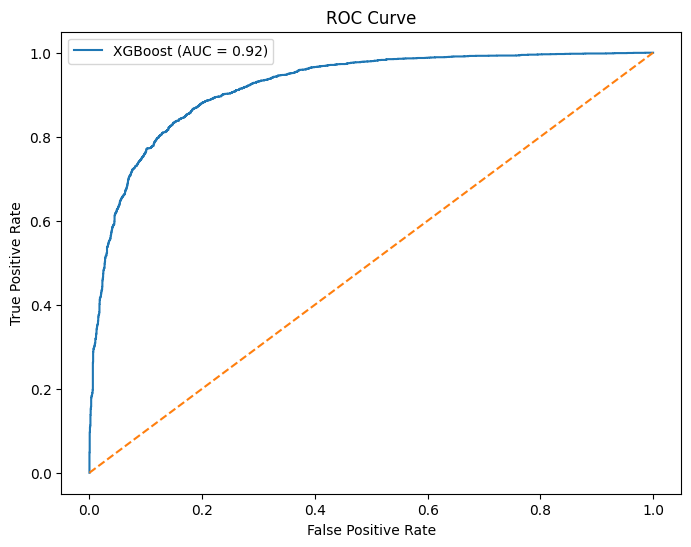

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.2f})')

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
# pahse 5------------------

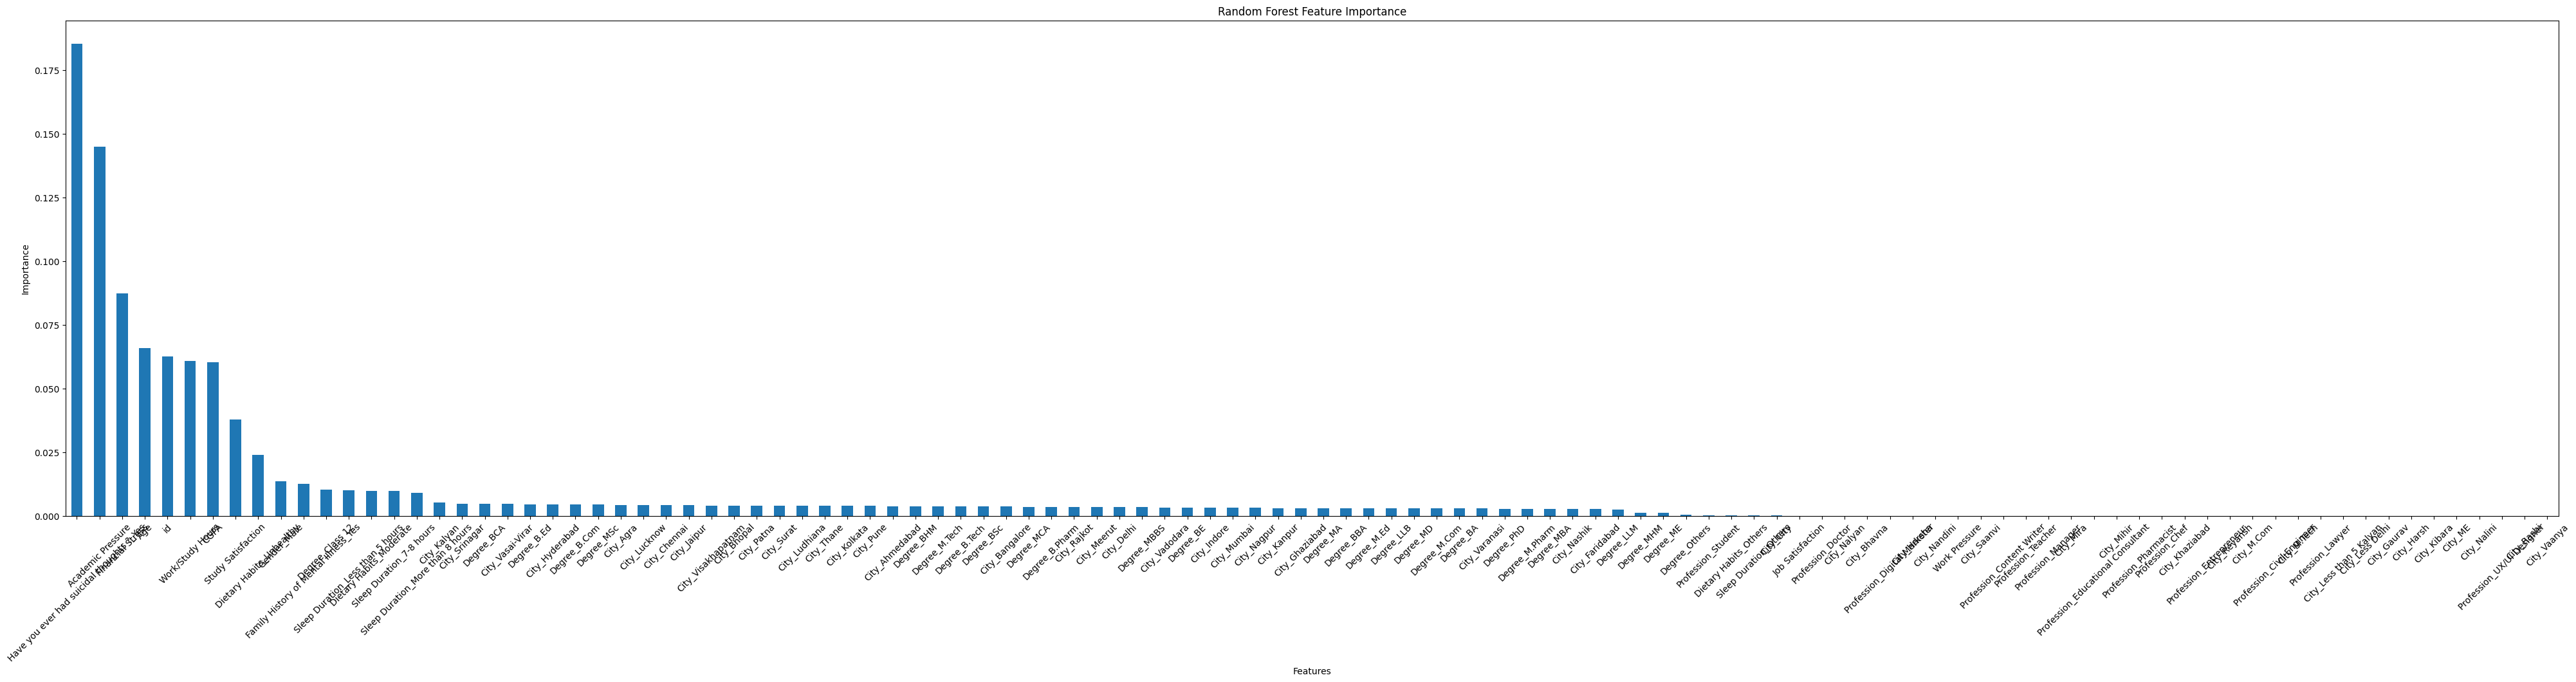

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a Series of feature importances
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(50, 10))
feature_importance.plot(kind='bar')

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap

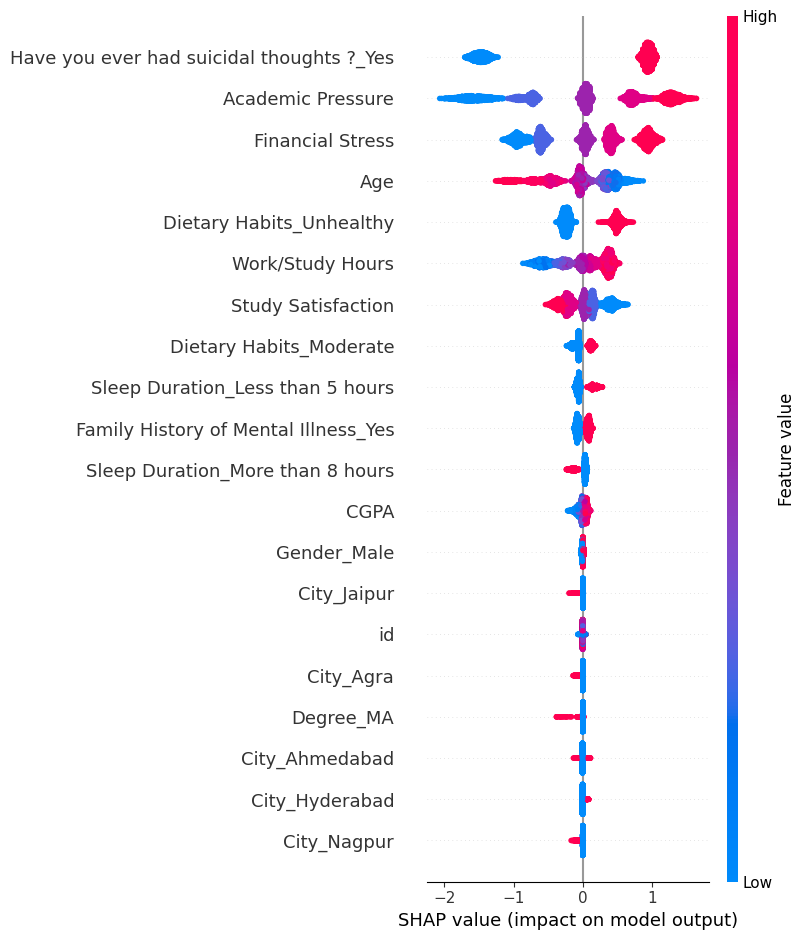

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

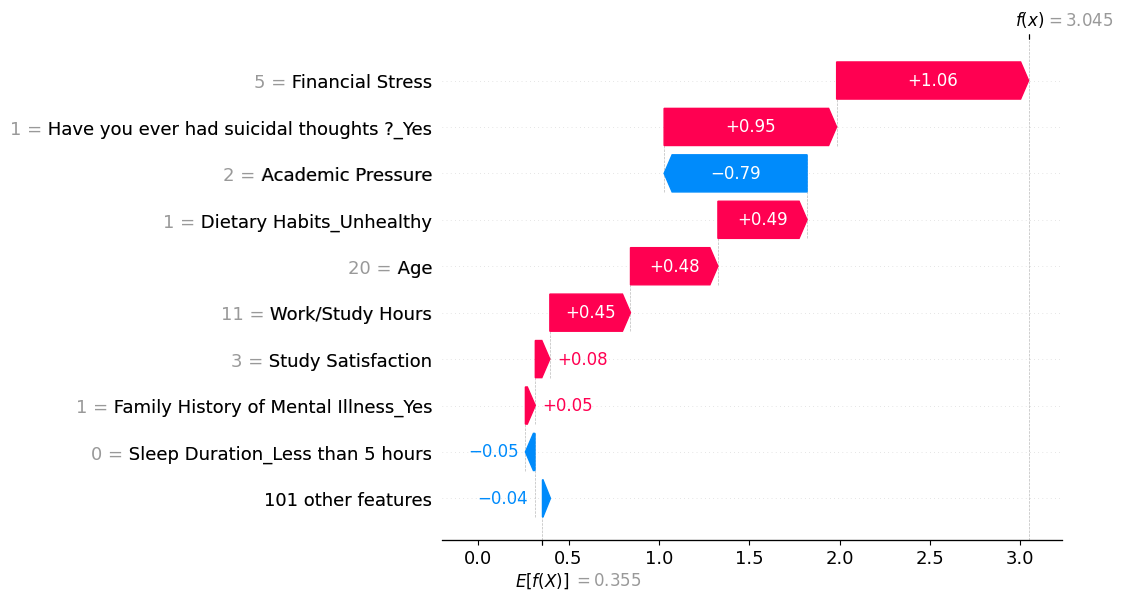

In [ ]:
import shap

explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

In [ ]:
import joblib

joblib.dump(xgb_model, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("best_model.pkl")

print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
prediction = loaded_model.predict(X_test)

print(prediction[:10])

[1 1 1 0 1 0 0 1 0 1]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.5 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import joblib
import pandas as pd

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
import os

print(os.listdir())

['.config', 'scaler.pkl', 'cleaned_student_depression.csv', 'best_model.pkl', 'sample_data']


In [ ]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Feature columns saved!")

AttributeError: 'numpy.ndarray' object has no attribute 'columns'